In [ ]:
from collections import defaultdict, deque
import itertools
import pathlib

In [ ]:
# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import igraph as ig
import iplotx
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-07-15T02:57:56.070242+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1059-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
matplotlib: 3.10.7
iplotx    : 1.7.1
numpy     : 2.1.2
marimo    : 0.23.2
seaborn   : 0.13.2
requests  : 2.34.2
igraph    : 0.11.9
pandas    : 2.2.3

```

# Estimated Community Assembly Graph from Invasibility

This notebook builds an **estimated community assembly graph** for the
3-site model (`N_SITES = 3`, 8 strains `000`..`111`) directly from the
**susceptibility snapshots** produced by the strain-persistence array
job (`2026-07-14-strain-persistence`). That job seeded every one of the
256 possible strain communities (one per `array_id`, its 8-bit binary
code selecting the seeded strains) and, every 1000 updates, recorded
the population's mean susceptibility to each of the 8 strains.

**Idea.** A community `C` (a set of resident strains) is *invasible* by
a rare strain `x` when `x`'s reproduction number while rare exceeds 1.
In this model that number is proportional to the mean population
susceptibility to `x` measured in the run that seeded `C`, so we read
invasibility straight off the susceptibility snapshot for
`array_id = bitmask(C)`. Starting from the `000` founder we repeatedly
let single-**mutation** neighbours of resident strains invade whenever
they clear the threshold, growing an assembly graph whose nodes are
communities and whose directed edges are invasions `C -> C + {x}`.

**Arrival-order relabeling (the same trick as the mutation-sweep
community-assembly notebook).** The three sites are exchangeable, so we
canonicalize each community by relabeling sites in **order of arrival**:
the site whose mutant allele arrives *first* becomes bit position 0, the
second-to-arrive bit position 1, the third bit position 2. This is
realized as the symmetry-minimal representative of the community, and it
collapses the 6 site-permutations of every community onto one canonical
node (e.g. all three single-mutant founders `001`/`010`/`100` become
`001`).

**Per-sample graphs.** Susceptibility drifts as herd immunity builds, so
invasibility --- and thus the assembly graph --- can change over time. We
loop over `teeplot` to draw one graph from the **first**, **second**, and
**third** 1000-update susceptibility sample (`window_end_update` = 1000,
2000, 3000).

In [ ]:
# CLI args; defaults pull the susceptibility parquet that backs this
# notebook (the strainlast parquet is optional annotation).
_args = mo.cli_args()
SUSC_SLUG = str(_args.get("susc-slug") or "jhnyk")
STRAINLAST_SLUG = str(_args.get("strainlast-slug") or "9pebz")
# Invasion threshold expressed as an R0-while-rare cutoff (a strain
# invades when its estimated reproduction number while rare exceeds
# this). 1.0 is the epidemic threshold.
R_THRESHOLD = float(_args.get("r-threshold") or 1.0)
# 1-based sample indices to draw (first, second, third 1000-update
# susceptibility windows).
SAMPLES = str(_args.get("samples") or "1,2,3")
SAMPLE_INDICES = [int(s) for s in SAMPLES.split(",") if s.strip()]
# Extinction-aware second graph set: the 1-based susceptibility sample to
# drive invasion (default 2 = the 2nd 1000-update window) and the
# extinction-time thresholds (updates) at which strains that have gone
# extinct in an assemblage's even-mix run are pruned before further
# additions.
EXT_SAMPLE = int(_args.get("extinction-sample") or 2)
EXT_STR = str(_args.get("extinction-thresholds") or "300,1000,3000,10000")
EXT_THRESHOLDS = [int(s) for s in EXT_STR.split(",") if s.strip()]
print(
    f"args: SUSC_SLUG={SUSC_SLUG} STRAINLAST_SLUG={STRAINLAST_SLUG} "
    f"R_THRESHOLD={R_THRESHOLD} SAMPLE_INDICES={SAMPLE_INDICES} "
    f"EXT_SAMPLE={EXT_SAMPLE} EXT_THRESHOLDS={EXT_THRESHOLDS}",
)

args: SUSC_SLUG=jhnyk STRAINLAST_SLUG=9pebz R_THRESHOLD=1.0 SAMPLE_INDICES=[1, 2, 3] EXT_SAMPLE=2 EXT_THRESHOLDS=[300, 1000, 3000, 10000]


In [ ]:
def download_parquet(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=180)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_parquet(cache_path)

In [ ]:
susc_df = download_parquet(SUSC_SLUG)
strainlast_df = download_parquet(STRAINLAST_SLUG)

N_SITES = int(susc_df["n_sites"].iloc[0])
N_STRAINS = 1 << N_SITES
CONTACT_RATE = float(susc_df["contact_rate"].iloc[0])
RECOVERY_RATE = float(susc_df["recovery_rate"].iloc[0])
WINDOW_ENDS = sorted(int(w) for w in susc_df["window_end_update"].unique())
print(f"susc: {susc_df.shape}  strainlast: {strainlast_df.shape}")
print(
    f"N_SITES={N_SITES} N_STRAINS={N_STRAINS} "
    f"CONTACT_RATE={CONTACT_RATE} RECOVERY_RATE={RECOVERY_RATE}",
)
print(
    f"n array_ids: {susc_df['array_id'].nunique()}  windows: {WINDOW_ENDS}"
)
N_STEPS = int(susc_df["n_steps"].iloc[0])

downloading https://osf.io/jhnyk/download -> /tmp/jhnyk
size: 79091 bytes
downloading https://osf.io/9pebz/download -> /tmp/9pebz
size: 14637 bytes
susc: (20480, 21)  strainlast: (2048, 19)
N_SITES=3 N_STRAINS=8 CONTACT_RATE=0.35 RECOVERY_RATE=0.1
n array_ids: 256  windows: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]


In [ ]:
# susc_map[(array_id, window_end_update)] -> length-N_STRAINS vector of
# mean susceptibility to each strain (genome integer) in that community.
def build_susc_map(df):
    out = {}
    for (aid, w), grp in df.groupby(["array_id", "window_end_update"]):
        vec = np.zeros(N_STRAINS)
        for strain, susc in zip(grp["strain"], grp["mean_susceptibility"]):
            vec[int(strain)] = float(susc)
        out[(int(aid), int(w))] = vec
    return out

susc_map = build_susc_map(susc_df)
print(f"susc_map entries: {len(susc_map)} (256 communities x windows)")

susc_map entries: 2560 (256 communities x windows)


In [ ]:
# A rare strain x invading community C has, per infectious host,
# ~CONTACT_RATE * susc new infections per update, and its deterministic
# infectious period contributes an R0 multiplier (1 - RECOVERY_RATE) /
# RECOVERY_RATE (the same multiplier the founder notebook uses: recovery
# runs after transmission within an update, so a primary infected at t
# transmits over sum_k (1-p)^k = (1-p)/p future updates). Hence
#   R0(x | C) = CONTACT_RATE * (1 - RECOVERY_RATE) / RECOVERY_RATE * susc
# and x invades when R0 > R_THRESHOLD, i.e. susc > SUSC_THRESHOLD.
R0_PER_SUSC = CONTACT_RATE * (1.0 - RECOVERY_RATE) / RECOVERY_RATE
SUSC_THRESHOLD = R_THRESHOLD / R0_PER_SUSC
print(
    f"R0 per unit susceptibility = {R0_PER_SUSC:.4f}; "
    f"invade when susc > {SUSC_THRESHOLD:.4f} "
    f"(R0 > {R_THRESHOLD})",
)

R0 per unit susceptibility = 3.1500; invade when susc > 0.3175 (R0 > 1.0)


## Build the Invasion Assembly Graph

**Canonicalization.** `canon(community)` relabels sites by arrival order,
implemented as the lexicographically-minimal genome set over the
`N_SITES!` site permutations. Because every site has identical
parameters, symmetric communities collapse to one canonical node and
the founder `000` and all-ones `111` are fixed points.

**Invasion step.** From canonical community `C` (with
`array_id = bitmask(C)`) the candidate invaders are the single-mutation
neighbours of resident strains that are not already present ---
`x = r ^ (1 << s)` for a resident `r` and site `s`. Strain `x` invades
when its measured susceptibility in `C`'s run exceeds `SUSC_THRESHOLD`;
the resulting community `canon(C + {x})` is the edge target.

**Assembly.** A breadth-first sweep from the `000` founder applies the
invasion step until no new community appears, yielding the directed
assembly graph for that susceptibility sample. Communities with no
admissible invader are **terminal** (uninvadable) assembly endpoints.

**Complement-pair end states.** A terminal community that harbours a
strain and its bitwise complement (`a` and `a ^ 111`) is a *converged*
end state --- the complement pair partitions the immune landscape and
stably coexists. Each such terminal converges to a **complement-pair end
node** (`000/111`, `001/110`, `010/101`, `011/100`); branches ending on
the same pair share that node. Complementation commutes with the
arrival-order relabeling, so the pairs are canonical too.

In [ ]:
_PERMS = list(itertools.permutations(range(N_SITES)))

def _permute_genome(g, perm):
    return sum((1 << perm[i]) for i in range(N_SITES) if (g >> i) & 1)

def canon_perm(community):
    """Canonical form plus the site permutation that produces it.

    Returns ``(canonical_set, perm)`` where ``perm`` maps site ``i`` of
    the input frame to site ``perm[i]`` of the canonical frame (the
    symmetry-minimal genome frozenset over all site permutations).
    """
    best_key = None
    best = None
    for perm in _PERMS:
        mapped = frozenset(_permute_genome(g, perm) for g in community)
        key = tuple(sorted(mapped))
        if best_key is None or key < best_key:
            best_key, best = key, (mapped, perm)
    return best

def canon(community):
    """Arrival-order canonical form: symmetry-minimal genome set.

    Relabels sites so the first-arriving site is bit 0, etc. Symmetric
    communities share one canonical node.
    """
    return canon_perm(community)[0]

def bitmask(community):
    m = 0
    for g in community:
        m |= 1 << g
    return int(m)

def invaders(community, window):
    """(strain, susceptibility) for admissible single-mutation invaders.

    Candidates are Hamming-1 neighbours of resident strains not already
    present; susceptibility is read from the community's own run
    (array_id = bitmask). Threshold comparison is left to the caller.
    """
    susc = susc_map[(bitmask(community), int(window))]
    cands = {
        r ^ (1 << s) for r in community for s in range(N_SITES)
    } - set(community)
    return sorted((x, float(susc[x])) for x in cands)

def build_assembly_graph(window, susc_threshold):
    """BFS from the 000 founder; returns (nodes, edges).

    nodes: set of canonical community frozensets.
    edges: dict (src_tuple, dst_tuple) -> (label, susc); every edge is a
    pure gain, labelled ``+<invader>`` in the source frame.
    """
    root = canon(frozenset({0}))
    nodes = {root}
    edges = {}
    queue = deque([root])
    while queue:
        community = queue.popleft()
        for strain, susc in invaders(community, window):
            if susc <= susc_threshold:
                continue
            child = canon(community | {strain})
            label = f"+{format(int(strain), f'0{N_SITES}b')}"
            edges[(tuple(sorted(community)), tuple(sorted(child)))] = (
                label,
                susc,
            )
            if child not in nodes:
                nodes.add(child)
                queue.append(child)
    return nodes, edges

In [ ]:
FULL = (1 << N_SITES) - 1  # all-ones strain (complement of the founder)

def binstr(g):
    return format(g, f"0{N_SITES}b")

def pair_key(a, b):
    """Canonical label for a complement pair, e.g. 000/111."""
    lo, hi = sorted((a, b))
    return f"{binstr(lo)}/{binstr(hi)}"

def community_pairs(community):
    """Complement pairs {a, a ^ FULL} with both members present.

    A terminal community harbouring such a pair is a *converged*
    assembly end state: a strain and its bitwise complement stably
    coexisting (they partition the immune landscape). Complementation
    commutes with the arrival-order relabeling, so canonical communities
    keep canonical pairs.
    """
    return sorted(
        pair_key(a, a ^ FULL)
        for a in community
        if (a ^ FULL) in community and a <= (a ^ FULL)
    )

# Outline colors for the complement-pair end states, mirroring the
# mutation-sweep community-assembly notebook: 000/111 (founder + all-ones)
# green, the remaining pairs each their own color.
PAIR_KEYS = [
    pair_key(s, s ^ FULL) for s in range(FULL + 1) if s <= s ^ FULL
]
_pair_palette = ["green", "#1f77b4", "#ff7f0e", "#9467bd", "#8c564b"]
END_OUTLINE = {
    pk: _pair_palette[i % len(_pair_palette)]
    for i, pk in enumerate(PAIR_KEYS)
}
END_OUTLINE["000/111"] = "green"

def terminal_pair_nodes(terminal):
    """Hollow complement-pair end nodes + convergence edges for terminals.

    Each terminal community harbouring a complement pair converges into
    the shared hollow pair node; branches ending on the same pair share
    the node.
    """
    pair_nodes = set()
    pair_edges = []
    for n in terminal:
        for pk in community_pairs(n):
            pair_nodes.add(pk)
            pair_edges.append((tuple(sorted(n)), pk))
    return pair_nodes, pair_edges

In [ ]:
def assembly_flow(nodes, edges, pair_edges):
    """Even-split assembly flow (visitation probability) per node.

    A uniform assembly walk starts at the 000 founder with unit weight;
    at every juncture the node's weight is split *evenly* among its
    outgoing edges (invasions, extinction transitions, or the convergence
    into a complement-pair end node). A node's flow is the total weight
    reaching it --- the probability the walk passes through it --- and the
    flow arriving at the terminal / pair end nodes partitions the unit
    weight across outcomes. The graph is a DAG (verified acyclic), so the
    flow is propagated in a Kahn topological order --- necessary once
    extinctions let a transition *shrink* a community rather than only
    grow it.
    """
    founder = frozenset({0})
    succ = defaultdict(list)
    all_nodes = set(nodes)
    for a, b in edges:
        succ[frozenset(a)].append(frozenset(b))
    for a, pk in pair_edges:
        succ[frozenset(a)].append(pk)
        all_nodes.add(pk)

    indeg = {n: 0 for n in all_nodes}
    for u in succ:
        for v in succ[u]:
            indeg[v] += 1
    queue = deque(n for n in all_nodes if indeg[n] == 0)
    topo = []
    while queue:
        u = queue.popleft()
        topo.append(u)
        for v in succ.get(u, []):
            indeg[v] -= 1
            if indeg[v] == 0:
                queue.append(v)

    flow = {n: 0.0 for n in all_nodes}
    flow[founder] = 1.0
    for node in topo:
        outs = succ.get(node, [])
        if outs:
            share = flow[node] / len(outs)
            for target in outs:
                flow[target] += share
    return flow

In [ ]:
# One assembly graph per requested susceptibility sample (1-based index
# into WINDOW_ENDS -> the window's end update).
graphs = {}
for _i in SAMPLE_INDICES:
    if not 1 <= _i <= len(WINDOW_ENDS):
        print(f"skipping sample {_i}: out of range 1..{len(WINDOW_ENDS)}")
        continue
    _w = WINDOW_ENDS[_i - 1]
    _nodes, _edges = build_assembly_graph(_w, SUSC_THRESHOLD)
    _srcs = {e[0] for e in _edges}
    _terminal = {n for n in _nodes if tuple(sorted(n)) not in _srcs}
    _pair_nodes, _pair_edges = terminal_pair_nodes(_terminal)
    _flow = assembly_flow(_nodes, _edges, _pair_edges)
    graphs[_i] = {
        "window_end": _w,
        "nodes": _nodes,
        "edges": _edges,
        "terminal": _terminal,
        "pair_nodes": _pair_nodes,
        "pair_edges": _pair_edges,
        "flow": _flow,
    }
    _pair_flow = {pk: _flow[pk] for pk in sorted(_pair_nodes)}
    print(
        f"sample {_i} (updates {_w - 1000 + 1}..{_w}): "
        f"{len(_nodes)} communities, {len(_edges)} invasions, "
        f"{len(_terminal)} terminal, "
        f"{len(_pair_nodes)} complement-pair end states; "
        f"end-state flow: "
        + ", ".join(f"{pk}={v:.2f}" for pk, v in _pair_flow.items()),
    )

sample 1 (updates 1..1000): 11 communities, 11 invasions, 5 terminal, 3 complement-pair end states; end-state flow: 000/111=0.25, 010/101=0.50, 011/100=0.25
sample 2 (updates 1001..2000): 11 communities, 11 invasions, 5 terminal, 3 complement-pair end states; end-state flow: 000/111=0.25, 010/101=0.50, 011/100=0.25
sample 3 (updates 2001..3000): 11 communities, 11 invasions, 5 terminal, 3 complement-pair end states; end-state flow: 000/111=0.25, 010/101=0.50, 011/100=0.25


In [ ]:
# last_map[array_id] -> length-N_STRAINS vector of last_observed_update
# (-1 for strains never seeded; N_STEPS for strains that never went
# extinct in that community's even-mix seeded run).
def build_last_map(df):
    out = {}
    for aid, grp in df.groupby("array_id"):
        vec = np.full(N_STRAINS, -1, dtype=int)
        for strain, last in zip(
            grp["strain"], grp["last_observed_update"]
        ):
            vec[int(strain)] = int(last)
        out[int(aid)] = vec
    return out

last_map = build_last_map(strainlast_df)
print(f"last_map entries: {len(last_map)}")

last_map entries: 256


## Assembly with Extinctions

The graph above lets every strain that can invade persist forever. This
second set of graphs instead uses the **strain-persistence dataset**
(`last_observed_update` per strain, per even-mix-seeded community) to
prune strains that go **extinct**, and asks how the assembly endpoints
change with the extinction time horizon.

- **Invasion** is driven by the **2nd 1000-update susceptibility sample**
  (`window_end_update = 2000`), exactly as above.
- **Extinction.** For an assemblage `C` (a community seeded as an even
  mix, `array_id = bitmask(C)`), a strain has gone extinct *before* update
  `T` when its `last_observed_update` in that run is `< T`. We keep only
  the strains surviving to `T`.
- **Ordering.** *Extinctions occur before further additions*: from a
  post-extinction community `C'` a single-mutation invader `x` is added,
  then the even-mix outcome of `C' + {x}` immediately prunes every strain
  not surviving to `T`, giving the next post-extinction community (which
  may be **smaller** than `C'`). Invasions that leave the surviving set
  unchanged are dropped.

One graph is drawn per extinction horizon `T` (updates) --- **300, 1000,
3000, 10000** --- with the same flow sizing, complement-pair end nodes,
and outcome-% annotations. As `T` grows, transient strains have more time
to be excluded, and the reachable endpoints collapse toward the stable
complement pairs.

In [ ]:
def _survivors_in_frame(community, threshold):
    """Members of `community` surviving to `threshold`, kept in the input
    frame (not re-canonicalized), so the gained/lost taxa can be read off
    in the *parent* frame. Survival is looked up in the community's own
    even-mix run via the permutation to its canonical array_id."""
    canonical, perm = canon_perm(community)
    last = last_map[bitmask(canonical)]

    def survives(g):
        mapped = sum(
            (1 << perm[i]) for i in range(N_SITES) if (g >> i) & 1
        )
        return last[mapped] >= threshold

    return frozenset(g for g in community if survives(g))

def survivors(community, threshold):
    return canon(_survivors_in_frame(community, threshold))

def build_extinction_graph(window, susc_threshold, ext_threshold):
    """Assembly with extinctions resolved before each further addition.

    BFS from the (post-extinction) 000 founder: from a post-extinction
    community C' an admissible single-mutation invader (window
    susceptibility > susc_threshold) is added, then the even-mix outcome
    of C' + {x} prunes strains not surviving to ext_threshold, giving the
    next post-extinction community. Each edge is labelled with the
    *parent-frame* net change --- ``+<invader>`` for the strain that
    established plus ``-<resident>`` for each resident it drove extinct.
    Self-transitions (surviving set unchanged) and collapses to the empty
    set are dropped.
    """
    root = survivors(canon(frozenset({0})), ext_threshold)
    nodes = {root}
    edges = {}
    queue = deque([root])
    while queue:
        community = queue.popleft()
        if not community:
            continue
        for strain, susc in invaders(community, window):
            if susc <= susc_threshold:
                continue
            assembled = community | {strain}
            surv = _survivors_in_frame(assembled, ext_threshold)
            nxt = canon(surv)
            if nxt == community or not nxt:
                continue
            gained = sorted(surv - community)
            lost = sorted(community - surv)
            label = " ".join(
                [f"+{format(g, f'0{N_SITES}b')}" for g in gained]
                + [f"-{format(g, f'0{N_SITES}b')}" for g in lost]
            )
            edges[(tuple(sorted(community)), tuple(sorted(nxt)))] = (
                label,
                susc,
            )
            if nxt not in nodes:
                nodes.add(nxt)
                queue.append(nxt)
    return nodes, edges

In [ ]:
ext_window = WINDOW_ENDS[EXT_SAMPLE - 1]
ext_graphs = {}
for _T in EXT_THRESHOLDS:
    _nodes, _edges = build_extinction_graph(ext_window, SUSC_THRESHOLD, _T)
    _srcs = {e[0] for e in _edges}
    _terminal = {n for n in _nodes if tuple(sorted(n)) not in _srcs}
    _pair_nodes, _pair_edges = terminal_pair_nodes(_terminal)
    _flow = assembly_flow(_nodes, _edges, _pair_edges)
    ext_graphs[_T] = {
        "window_end": ext_window,
        "extinct_before": _T,
        "nodes": _nodes,
        "edges": _edges,
        "terminal": _terminal,
        "pair_nodes": _pair_nodes,
        "pair_edges": _pair_edges,
        "flow": _flow,
    }
    _pf = {pk: _flow[pk] for pk in sorted(_pair_nodes)}
    print(
        f"extinct<{_T}: {len(_nodes)} communities, {len(_edges)} "
        f"transitions, {len(_terminal)} terminal; end-state flow: "
        + ", ".join(f"{pk}={v:.2f}" for pk, v in _pf.items()),
    )

extinct<300: 11 communities, 11 transitions, 5 terminal; end-state flow: 000/111=0.25, 001/110=0.50, 010/101=0.25
extinct<1000: 6 communities, 6 transitions, 2 terminal; end-state flow: 000/111=0.25, 001/110=0.75
extinct<3000: 6 communities, 6 transitions, 2 terminal; end-state flow: 000/111=0.25, 001/110=0.75
extinct<10000: 6 communities, 6 transitions, 2 terminal; end-state flow: 000/111=0.25, 001/110=0.75


In [ ]:
# Text dump of the first requested sample's assembly graph.
def _binset(t):
    return "{" + ",".join(format(g, f"0{N_SITES}b") for g in t) + "}"

if graphs:
    _i = sorted(graphs)[0]
    _g = graphs[_i]
    print(f"sample {_i} (window end {_g['window_end']}):")
    for (a, b), (label, susc) in sorted(
        _g["edges"].items(), key=lambda kv: (len(kv[0][0]), kv[0])
    ):
        print(
            f"  {_binset(a)} --[{label}] (susc={susc:.3f})--> "
            f"{_binset(b)}"
        )

sample 1 (window end 1000):
  {000} --[+100] (susc=0.428)--> {000,001}
  {000,001} --[+100] (susc=0.447)--> {000,001,010}
  {000,001} --[+101] (susc=0.449)--> {000,001,011}
  {000,001,010} --[+100] (susc=0.443)--> {000,001,010,100}
  {000,001,010} --[+110] (susc=0.495)--> {000,001,010,101}
  {000,001,011} --[+100] (susc=0.489)--> {000,001,010,101}
  {000,001,011} --[+101] (susc=0.444)--> {000,001,011,101}
  {000,001,011} --[+111] (susc=0.494)--> {000,001,011,111}
  {000,001,010,100} --[+110] (susc=0.366)--> {000,001,010,011,100}
  {000,001,011,101} --[+100] (susc=0.366)--> {000,001,010,011,101}
  {000,001,011,101} --[+111] (susc=0.366)--> {000,001,011,101,111}


## Plot the Assembly Graphs

One directed community assembly graph per susceptibility sample,
rendered with `iplotx` (matplotlib backend) via a `teeplot` loop.
Communities are laid out left-to-right by the **number of resident
strains**, so assembly reads left-to-right as depth from the `000`
founder (every edge points rightward). Node fill encodes the community
via the color key; the number on each node is the count of resident
strains. The `000` founder is outlined **green**.

**Node size** encodes the **even-split assembly flow**: a uniform
assembly walk starts at the founder with unit weight and splits its
weight *evenly* among the available invasions at each juncture, so a
node's area is proportional to the probability the walk passes through
it. The flow arriving at the terminal and complement-pair end nodes
partitions the unit weight across outcomes (printed above).

Each **complement-pair end state** is drawn as a **hollow circle with a
color-coded outline** (`000/111` green, the other pairs their own colors)
sharing the rightmost column; a terminal community converges into the
hollow pair node it harbours. A terminal community that harbours *no*
complement pair (an unresolved endpoint) is instead outlined **red**.

Each edge is optionally labelled with the **taxon gained** (`+<strain>`,
the strain that established) and, in the extinction graphs, any **taxa
lost** (`-<strain>`, residents driven extinct by the addition), expressed
in the source community's arrival-order frame (convergence edges into the
pair nodes are unlabelled). Two versions are saved per graph (tagged
`edge-labels=strain-susc` vs `edge-labels=none`).

In [ ]:
def layout_dag(nodes, edges, np):
    """Sugiyama-style layered layout: x = longest-path depth from the 000
    founder, so every edge points rightward (no backward arrows even when
    an extinction transition shrinks a community); y spreads a layer and
    is barycenter-ordered against the previous layer to limit crossings.
    Returns ``(coords, max_depth)``.
    """
    nodeset = set(nodes)
    succ = defaultdict(list)
    pred = defaultdict(list)
    indeg = {n: 0 for n in nodeset}
    for a, b in edges:
        A, B = frozenset(a), frozenset(b)
        if A in nodeset and B in nodeset:
            succ[A].append(B)
            pred[B].append(A)
            indeg[B] += 1

    # Kahn topological order, then longest-path depth from the sources.
    ind = dict(indeg)
    queue = deque(n for n in nodeset if ind[n] == 0)
    topo = []
    while queue:
        u = queue.popleft()
        topo.append(u)
        for v in succ.get(u, []):
            ind[v] -= 1
            if ind[v] == 0:
                queue.append(v)
    depth = {n: 0 for n in nodeset}
    for u in topo:
        for v in succ.get(u, []):
            depth[v] = max(depth[v], depth[u] + 1)

    layers = defaultdict(list)
    for n in nodeset:
        layers[depth[n]].append(n)
    order = {
        d: sorted(layers[d], key=lambda k: tuple(sorted(k)))
        for d in layers
    }
    for _ in range(6):  # barycenter crossing-reduction sweeps
        for d in sorted(order):
            if d == 0:
                continue
            prev_idx = {n: i for i, n in enumerate(order.get(d - 1, []))}
            mid = len(order[d]) / 2.0

            def _bary(n, _prev_idx=prev_idx, _mid=mid):
                ps = [_prev_idx[p] for p in pred[n] if p in _prev_idx]
                return sum(ps) / len(ps) if ps else _mid

            order[d] = sorted(order[d], key=_bary)

    coords = {}
    for d in order:
        layer = order[d]
        m = len(layer)
        ys = (
            np.linspace(-(m - 1) / 2.0, (m - 1) / 2.0, m)
            if m > 1
            else [0.0]
        )
        for k, y in zip(layer, ys):
            coords[k] = (float(d), float(y) * 1.7)
    return coords, max(depth.values(), default=0)

In [ ]:
def _binset(community):
    return ", ".join(format(g, f"0{N_SITES}b") for g in sorted(community))

def _nid(k):
    # Node id: sorted-genome tuple for a community, the string for a
    # complement-pair end node.
    return tuple(sorted(k)) if isinstance(k, frozenset) else k

def plot_graph(bundle, ax, legend_ax, palette="husl", edge_labels=True):
    comm_set = bundle["nodes"]
    edges = bundle["edges"]
    terminal = bundle["terminal"]
    pair_nodes = bundle["pair_nodes"]
    pair_edges = bundle["pair_edges"]
    flow = bundle["flow"]
    founder = frozenset({0})

    # Node size encodes the even-split assembly flow (visitation
    # probability): area proportional to flow, so radius ~ sqrt(flow).
    max_flow = max(flow.values()) if flow else 1.0

    def vsize(k):
        return 12.0 + 34.0 * np.sqrt(flow.get(k, 0.0) / max_flow)

    # Terminal communities that resolve to a complement pair (vs. an
    # unresolved "U"-like endpoint that harbours no pair). pair_edges
    # store sorted-tuple sources, so rebuild as frozensets to match the
    # community node keys.
    resolved = {frozenset(a) for a, _pk in pair_edges}

    communities = sorted(
        comm_set, key=lambda k: (len(k), tuple(sorted(k)))
    )

    # Layout: longest-path depth from the founder (edges point rightward);
    # complement-pair end nodes share the rightmost column, ordered by the
    # mean height of their source communities to limit crossings.
    coords, maxdepth = layout_dag(comm_set, edges, np)
    src_y = defaultdict(list)
    for a, pk in pair_edges:
        src_y[pk].append(coords[frozenset(a)][1])
    pairs = sorted(
        pair_nodes,
        key=lambda pk: sum(src_y[pk]) / max(len(src_y[pk]), 1),
    )
    m = len(pairs)
    ys = np.linspace(-(m - 1) / 2.0, (m - 1) / 2.0, m) if m > 1 else [0.0]
    for pk, y in zip(pairs, ys):
        coords[pk] = (float(maxdepth + 1), float(y) * 1.8)

    nodes = communities + pairs  # community nodes first, pair nodes last
    idx = {_nid(k): i for i, k in enumerate(nodes)}

    colors = sns.color_palette(palette, n_colors=max(3, len(communities)))
    colormap = {k: colors[i] for i, k in enumerate(communities)}

    g = ig.Graph(directed=True)
    g.add_vertices(len(nodes))
    elist, ewidth, elabel = [], [], []
    max_susc = max((s for _lbl, s in edges.values()), default=1.0)
    for (a, b), (label, susc) in edges.items():
        elist.append((idx[a], idx[b]))
        ewidth.append(1.0 + 3.5 * (susc / max_susc))
        elabel.append(label)
    for a, pk in pair_edges:  # convergence into the pair end node
        elist.append((idx[a], idx[pk]))
        ewidth.append(2.0)
        elabel.append("")
    g.add_edges(elist)

    vsizes, vface, vedge, vlw, vlabel = [], [], [], [], []
    for k in nodes:
        vsizes.append(vsize(k))
        if isinstance(k, str):  # complement-pair end node: hollow + coded
            vface.append("white")
            vedge.append(END_OUTLINE.get(k, "black"))
            vlw.append(3.0)
            vlabel.append("2")
        else:
            vface.append(colormap[k])
            if k == founder:
                vedge.append("green")
                vlw.append(3.0)
            elif k in terminal and k not in resolved:
                vedge.append("red")  # unresolved endpoint (no pair)
                vlw.append(3.0)
            else:
                vedge.append("black")
                vlw.append(1.0)
            vlabel.append(str(len(k)))

    iplotx.network(
        g,
        layout=[coords[k] for k in nodes],
        vertex_labels=vlabel,
        edge_labels=(elabel if edge_labels else None),
        ax=ax,
        vertex_facecolor=vface,
        vertex_edgecolor=vedge,
        vertex_size=vsizes,
        vertex_linewidth=vlw,
        edge_linewidth=ewidth,
        edge_color="0.55",
        vertex_label_color="black",
        vertex_label_size=9,
        edge_label_size=6,
        edge_label_rotate=False,
        show=False,
    )
    ax.margins(0.12)

    # Annotate each hollow complement-pair end node with its outcome %
    # (the even-split flow arriving there) just to its right.
    for pk in pairs:
        px, py = coords[pk]
        ax.text(
            px + 0.55,
            py,
            f"{flow.get(pk, 0.0) * 100:.0f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color=END_OUTLINE.get(pk, "black"),
        )
    if pairs:
        _xlo, _xhi = ax.get_xlim()
        ax.set_xlim(_xlo, max(_xhi, maxdepth + 2.2))

    # color-coded key: communities (filled) then complement-pair end
    # states (hollow, color-coded outline).
    legend_ax.axis("off")
    handles, labels = [], []
    for k in communities:
        if k == founder:
            outline, mew, suffix = "green", 1.8, "  (founder)"
        elif k in terminal and k not in resolved:
            outline, mew, suffix = "red", 1.8, "  (terminal, no pair)"
        else:
            outline, mew, suffix = "black", 0.6, ""
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=colormap[k],
                markeredgecolor=outline,
                markeredgewidth=mew,
                markersize=9,
            )
        )
        labels.append(f"{{{_binset(k)}}}{suffix}")
    for pk in pairs:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="white",
                markeredgecolor=END_OUTLINE.get(pk, "black"),
                markeredgewidth=2.0,
                markersize=9,
            )
        )
        labels.append(f"{pk}  (complement-pair end state)")
    legend_ax.legend(
        handles,
        labels,
        loc="center left",
        fontsize=6.5,
        title="community (resident strains)",
        title_fontsize=8,
        ncol=1 if len(handles) <= 16 else 2,
        frameon=False,
        handletextpad=0.4,
        labelspacing=0.3,
        borderaxespad=0.0,
    )

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=strain-susc+sample=1+window-end=1000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=strain-susc+sample=1+window-end=1000+ext=.png


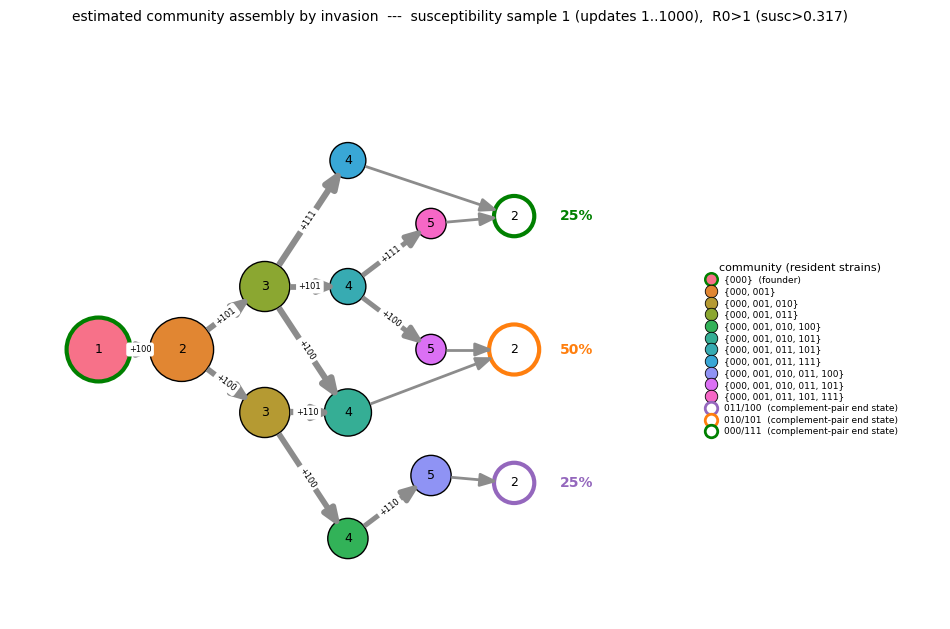

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=none+sample=1+window-end=1000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=none+sample=1+window-end=1000+ext=.png


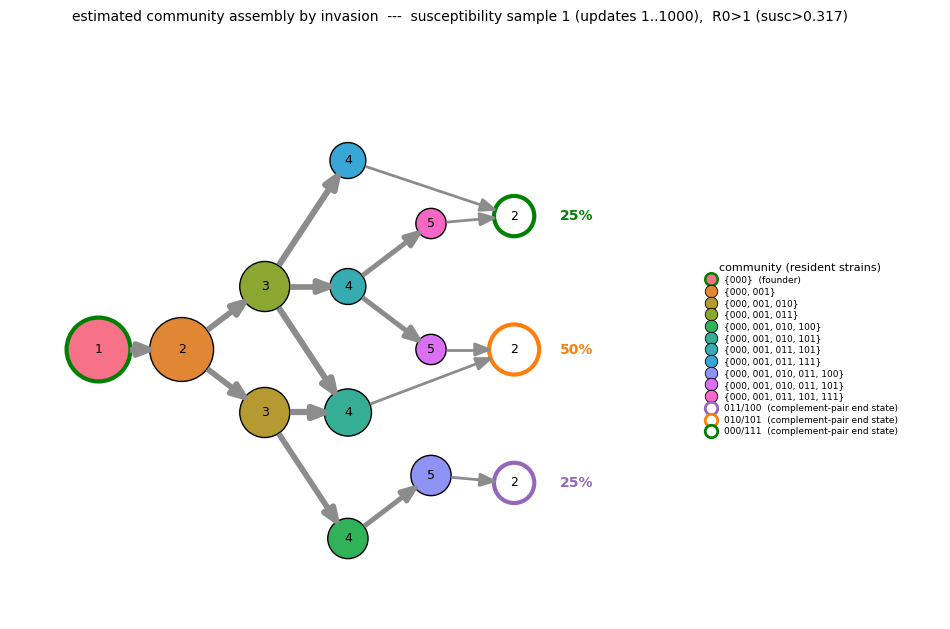

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=strain-susc+sample=2+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=strain-susc+sample=2+window-end=2000+ext=.png


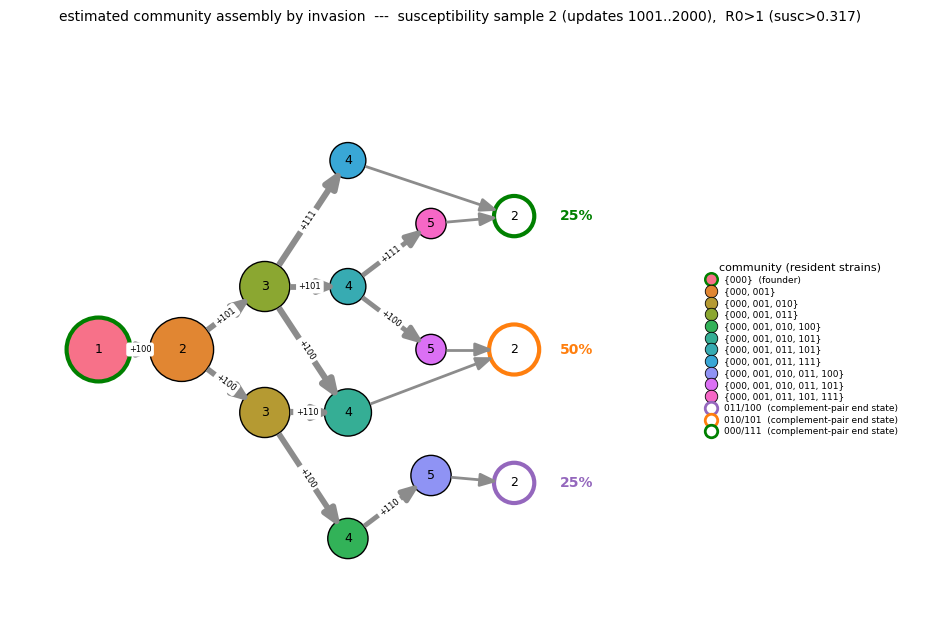

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=none+sample=2+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=none+sample=2+window-end=2000+ext=.png


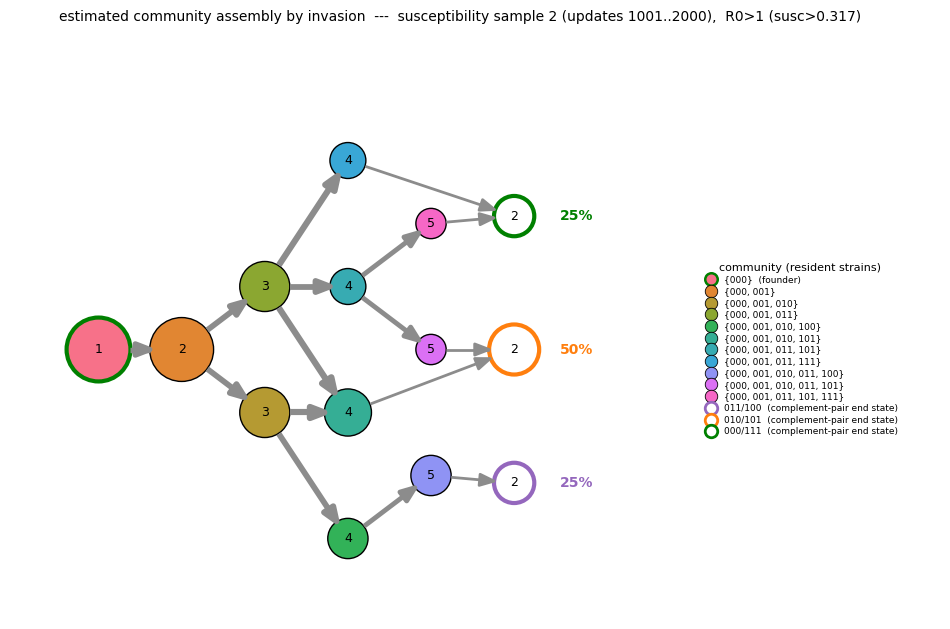

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=strain-susc+sample=3+window-end=3000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=strain-susc+sample=3+window-end=3000+ext=.png


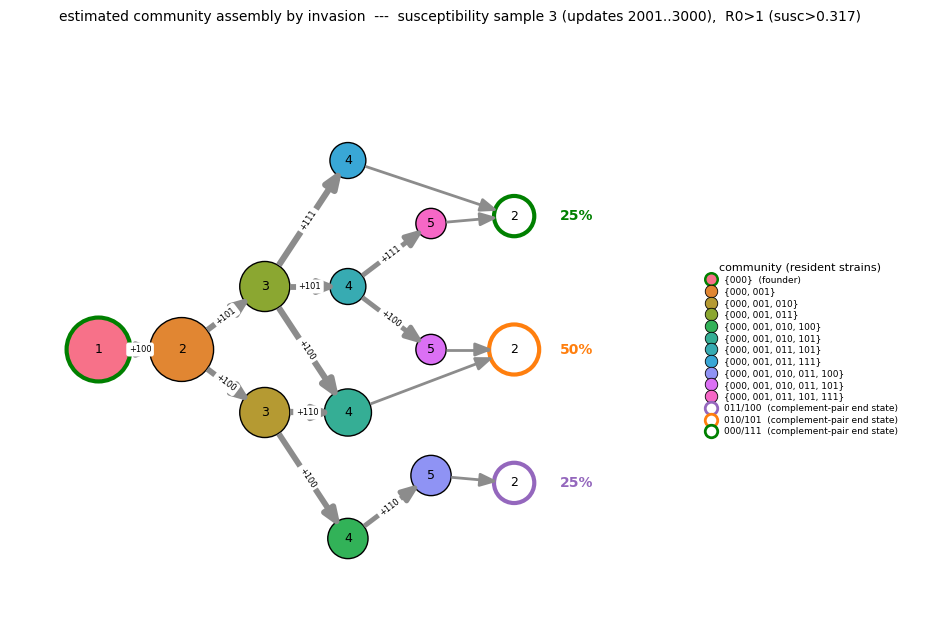

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=none+sample=3+window-end=3000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-invasion-graph+edge-labels=none+sample=3+window-end=3000+ext=.png


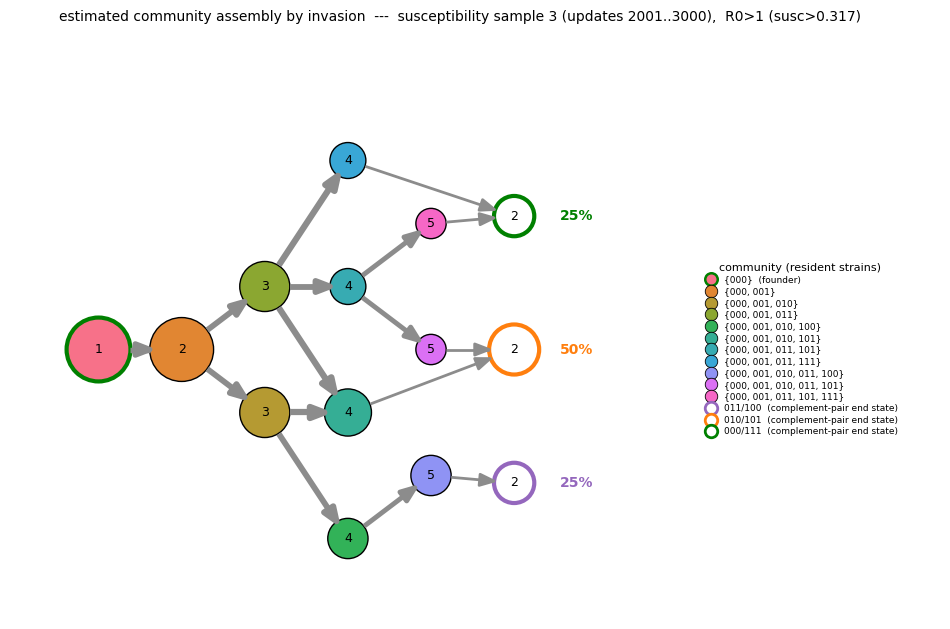

In [ ]:
# Loop over teeplot: one assembly graph per susceptibility sample, in two
# versions (edge labels vs bare arrows), tagged apart via teeplot_outattrs.
for _i in sorted(graphs):
    _bundle = graphs[_i]
    _w = _bundle["window_end"]

    def _factory(**kwargs):
        fig, (ax, lax) = plt.subplots(
            1, 2, gridspec_kw={"width_ratios": [3, 1.2]}, **kwargs
        )
        return fig, (ax, lax)

    for _edge_labels, _tag in [(True, "strain-susc"), (False, "none")]:
        with tp.teed(
            _factory,
            figsize=(12, 7),
            teeplot_outattrs={
                "a": "community-assembly-invasion-graph",
                "sample": f"{_i}",
                "window-end": f"{_w}",
                "edge-labels": _tag,
            },
            teeplot_outexclude="viz",
            teeplot_show=True,
            teeplot_subdir=pathlib.Path(__file__).stem,
        ) as (_fig, (_ax, _lax)):
            plot_graph(_bundle, _ax, _lax, edge_labels=_edge_labels)
            _fig.suptitle(
                f"estimated community assembly by invasion  ---  "
                f"susceptibility sample {_i} (updates {_w - 1000 + 1}"
                f"..{_w}),  R0>{R_THRESHOLD:g} "
                f"(susc>{SUSC_THRESHOLD:.3f})",
                fontsize=10,
            )

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=300+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=300+window-end=2000+ext=.png


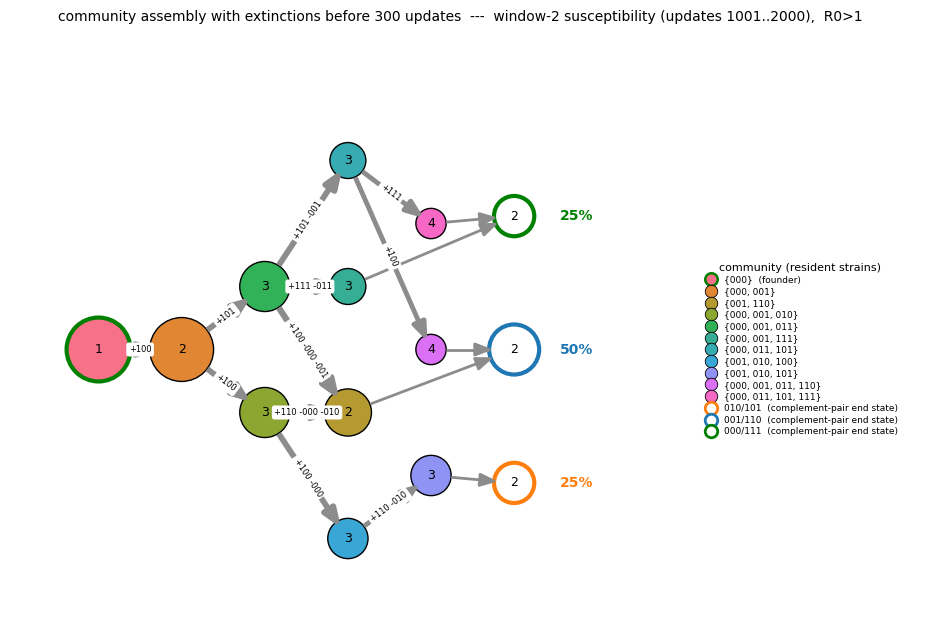

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=300+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=300+window-end=2000+ext=.png


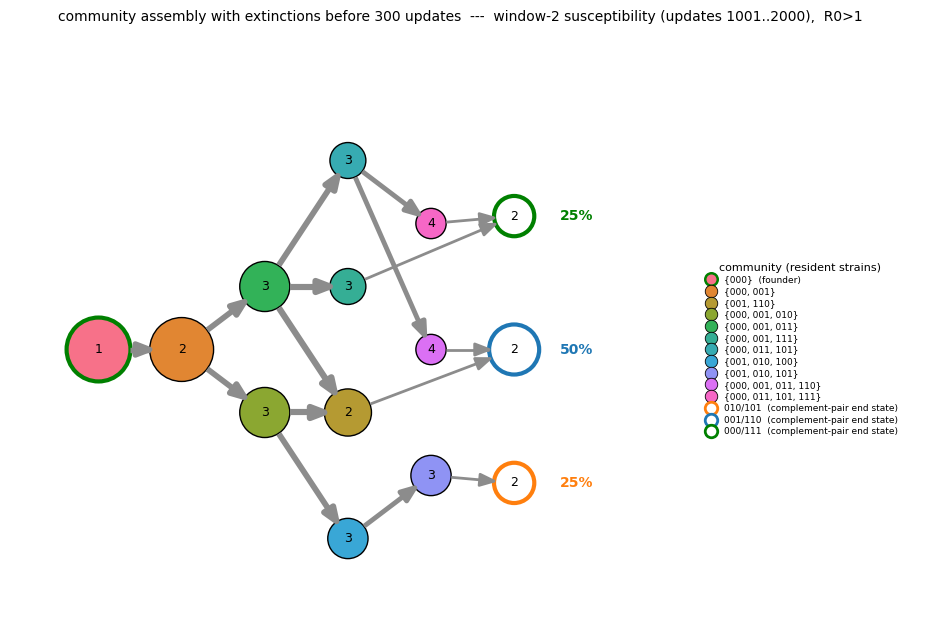

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=1000+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=1000+window-end=2000+ext=.png


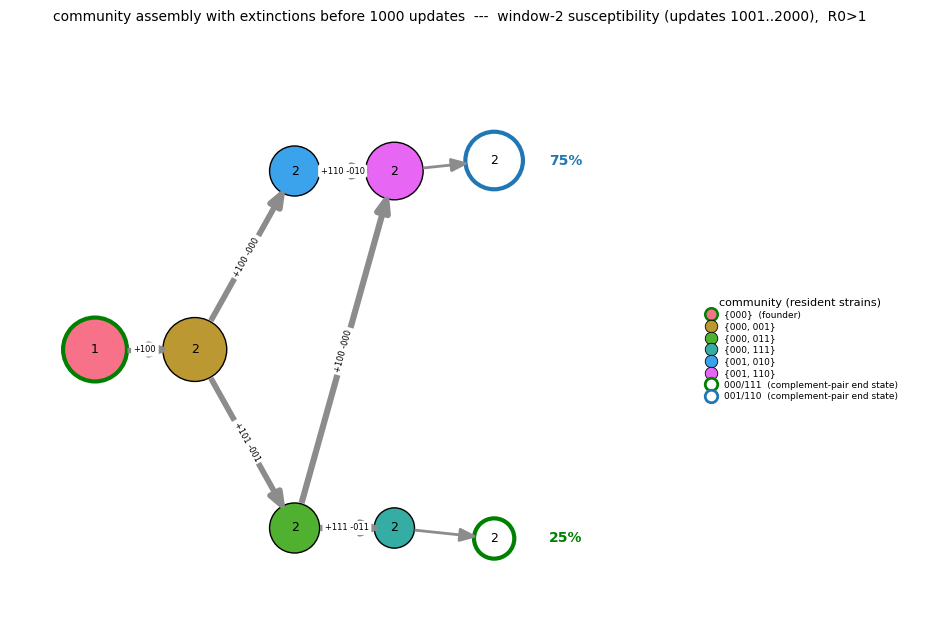

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=1000+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=1000+window-end=2000+ext=.png


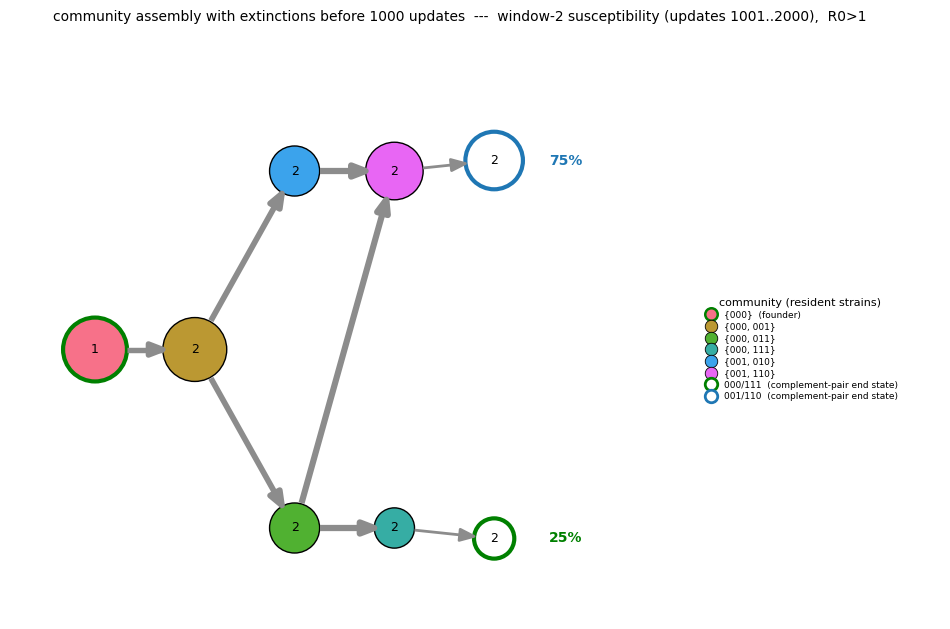

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=3000+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=3000+window-end=2000+ext=.png


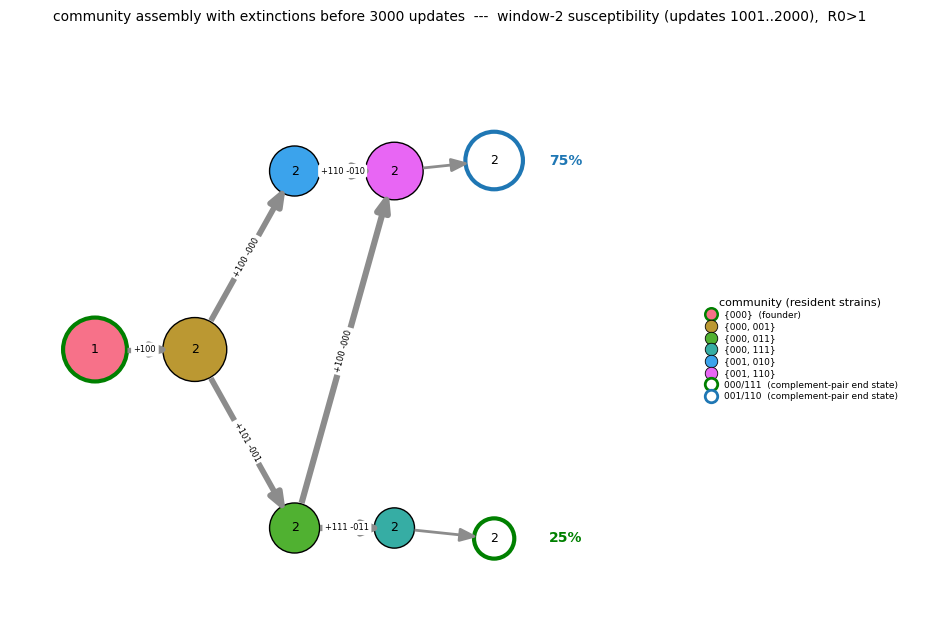

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=3000+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=3000+window-end=2000+ext=.png


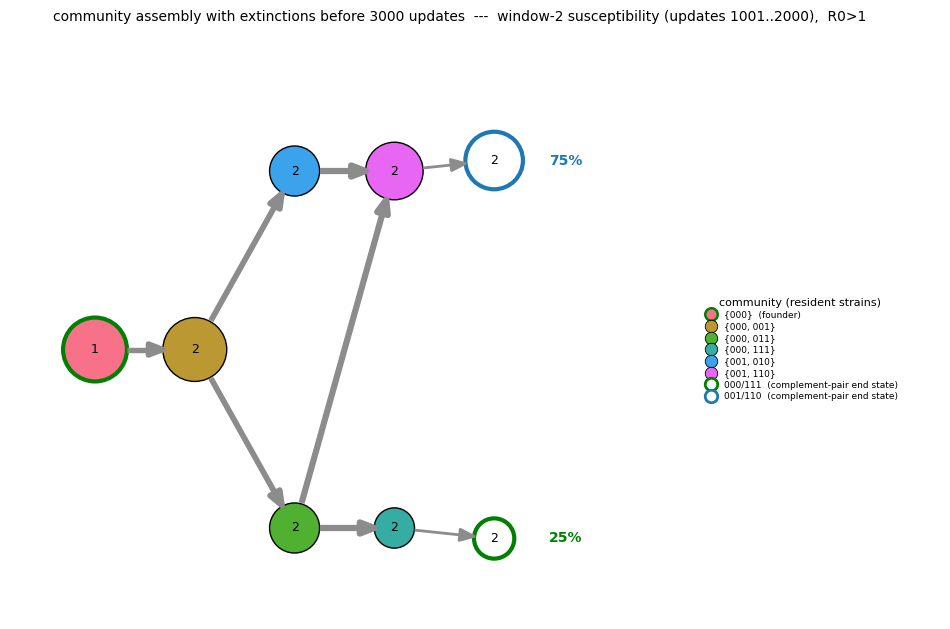

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=10000+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=strain-susc+extinct-before=10000+window-end=2000+ext=.png


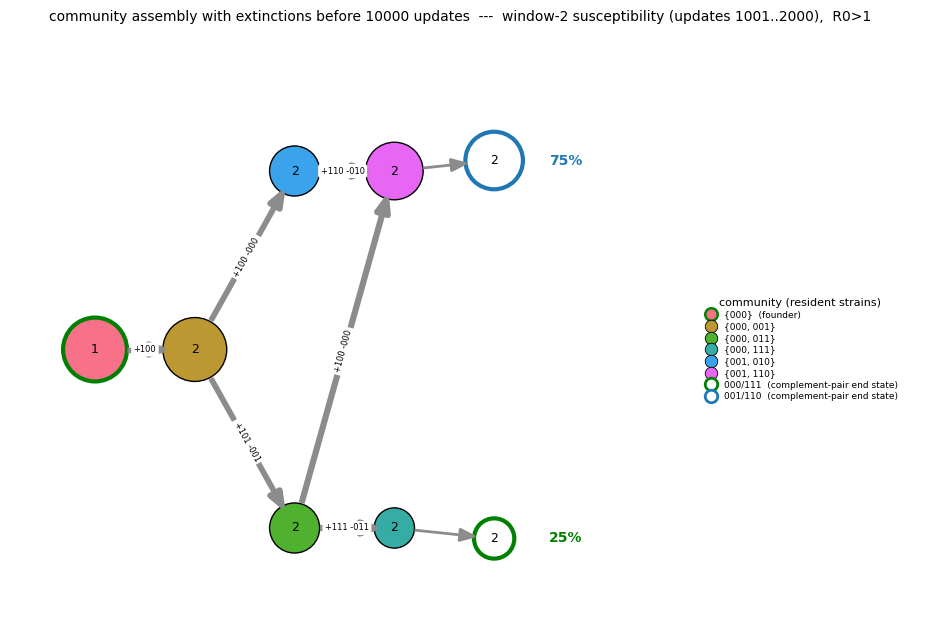

teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=10000+window-end=2000+ext=.pdf
teeplots/2026-07-14-community-assembly-invasion/a=community-assembly-extinction-graph+edge-labels=none+extinct-before=10000+window-end=2000+ext=.png


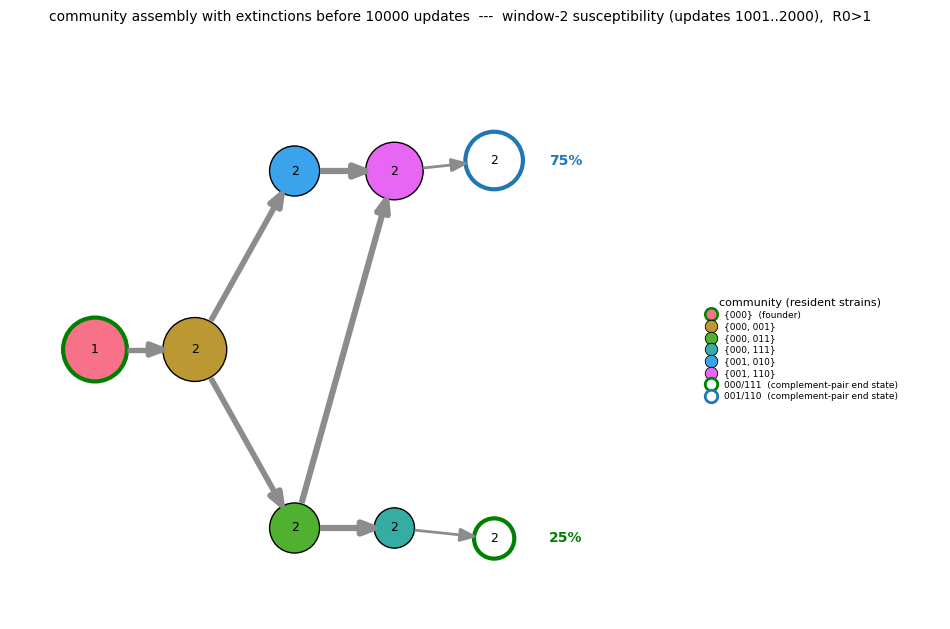

In [ ]:
# Loop over teeplot: one extinction-aware assembly graph per extinction
# horizon T, in two versions (edge labels vs bare arrows).
for _T in sorted(ext_graphs):
    _bundle = ext_graphs[_T]

    def _factory(**kwargs):
        fig, (ax, lax) = plt.subplots(
            1, 2, gridspec_kw={"width_ratios": [3, 1.2]}, **kwargs
        )
        return fig, (ax, lax)

    for _edge_labels, _tag in [(True, "strain-susc"), (False, "none")]:
        with tp.teed(
            _factory,
            figsize=(12, 7),
            teeplot_outattrs={
                "a": "community-assembly-extinction-graph",
                "extinct-before": f"{_T}",
                "window-end": f"{ext_window}",
                "edge-labels": _tag,
            },
            teeplot_outexclude="viz",
            teeplot_show=True,
            teeplot_subdir=pathlib.Path(__file__).stem,
        ) as (_fig, (_ax, _lax)):
            plot_graph(_bundle, _ax, _lax, edge_labels=_edge_labels)
            _fig.suptitle(
                f"community assembly with extinctions before {_T} "
                f"updates  ---  window-2 susceptibility "
                f"(updates {ext_window - 1000 + 1}..{ext_window}),  "
                f"R0>{R_THRESHOLD:g}",
                fontsize=10,
            )